#Assignment 1

##SMS Spam Classifier

Objective: Build a binary text classifier to identify whether an incoming SMS is "Spam" or "Ham" (legitimate).

Dataset Link https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

### Extracting the dataset

In [1]:
import zipfile
import os

# Path to the uploaded zip file
zip_file_path = '/content/archive (5).zip'

# Directory to extract the contents
extraction_path = '/content/datasets'

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Files extracted to: {extraction_path}")
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(extraction_path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Files extracted to: /content/datasets
Contents of the extracted directory:
/content/datasets/spam.csv


Task 1:

Clean the text by removing punctuation, converting to lowercase, and dropping common stop words.

In [12]:
import pandas as pd
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
import os

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

possible_paths = [
    os.path.join(extraction_path, 'spam.csv'),
    os.path.join(extraction_path, 'SMSSpamCollection'),
    os.path.join(extraction_path, 'smsspamcollection/SMSSpamCollection'),
    os.path.join(extraction_path, 'sms_spam_collection/SMSSpamCollection')
]

df_sms = None
for path in possible_paths:
    if os.path.exists(path):
        if 'SMSSpamCollection' in path:
            df_sms = pd.read_csv(path, sep='\t', header=None, names=['label', 'message'])
        else:
            try:
                df_sms = pd.read_csv(path, encoding='utf-8')
            except UnicodeDecodeError:
                df_sms = pd.read_csv(path, encoding='latin-1')

            if 'v1' in df_sms.columns and 'v2' in df_sms.columns:
                df_sms = df_sms.rename(columns={'v1': 'label', 'v2': 'message'})
                df_sms = df_sms[['label', 'message']] # Keep only relevant columns

        print(f"SMS Spam dataset loaded from: {path}")
        break

if df_sms is None:
    print("Could not find a common SMS Spam dataset file. Please specify the correct file name and path from the extracted files.")
else:
    print(f"Initial SMS DataFrame head:\n{df_sms.head()}")
    print(f"Initial SMS DataFrame info:\n{df_sms.info()}")

    def clean_text(text):
        # Convert to lowercase
        text = text.lower()
        # Remove punctuation
        text = ''.join([char for char in text if char not in string.punctuation])
        # Tokenize words
        tokens = word_tokenize(text)
        # Remove stopwords
        stop_words = set(stopwords.words('english'))
        tokens = [word for word in tokens if word not in stop_words]
        # Join back into a string
        return ' '.join(tokens)

    if df_sms is not None and 'message' in df_sms.columns:
        df_sms['cleaned_message'] = df_sms['message'].apply(clean_text)
        print(f"\nCleaned SMS DataFrame head:\n{df_sms.head()}")
    else:
        print("DataFrame or 'message' column not found for cleaning.")

SMS Spam dataset loaded from: /content/datasets/spam.csv
Initial SMS DataFrame head:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
Initial SMS DataFrame info:
None

Cleaned SMS DataFrame head:
  label                                            message  \
0   ham  Go until jurong point, crazy.. Available only ...   
1   ham                      Ok lar... Joking wif u oni...   
2  spam  Free entr

Task 2:

Convert texts into numerical formats using CountVectorizer or TfidfVectorizer from scikit-learn.

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

if df_sms is not None and 'cleaned_message' in df_sms.columns:
    # Initialize CountVectorizer
    vectorizer = CountVectorizer()

    # Fit and transform the cleaned messages
    X_sms = vectorizer.fit_transform(df_sms['cleaned_message'])

    print(f"Shape of vectorized SMS data: {X_sms.shape}")
    print(f"First 50 feature names:\n{vectorizer.get_feature_names_out()[:50]}")
else:
    print("SMS DataFrame or 'cleaned_message' column not found for vectorization.")

Shape of vectorized SMS data: (5572, 9372)
First 50 feature names:
['008704050406' '0089my' '0121' '01223585236' '01223585334' '0125698789'
 '02' '020603' '0207' '02070836089' '02072069400' '02073162414'
 '02085076972' '020903' '021' '050703' '0578' '06' '060505' '061104'
 '07008009200' '07046744435' '07090201529' '07090298926' '07099833605'
 '071104' '07123456789' '0721072' '07732584351' '07734396839'
 '07742676969' '07753741225' '0776xxxxxxx' '07786200117' '077xxx' '078'
 '07801543489' '07808' '07808247860' '07808726822' '07815296484'
 '07821230901' '0784987' '0789xxxxxxx' '0794674629107880867867'
 '0796xxxxxx' '07973788240' '07xxxxxxxxx' '0800' '08000407165']


Task 3:

Split data into an 80/20 train-test ratio.Train a Naive Bayes or Logistic Regression classifier.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder

if df_sms is not None and 'label' in df_sms.columns and 'cleaned_message' in df_sms.columns:
    # Convert labels to numerical format (0 for ham, 1 for spam)
    label_encoder = LabelEncoder()
    y_sms = label_encoder.fit_transform(df_sms['label'])

    # Split data into training and testing sets
    X_train_sms, X_test_sms, y_train_sms, y_test_sms = train_test_split(X_sms, y_sms, test_size=0.2, random_state=42)

    print(f"Shape of X_train_sms: {X_train_sms.shape}")
    print(f"Shape of X_test_sms: {X_test_sms.shape}")
    print(f"Shape of y_train_sms: {y_train_sms.shape}")
    print(f"Shape of y_test_sms: {y_test_sms.shape}")

    # Train a Multinomial Naive Bayes classifier
    nb_classifier_sms = MultinomialNB()
    nb_classifier_sms.fit(X_train_sms, y_train_sms)

    print("Multinomial Naive Bayes classifier trained successfully.")
else:
    print("SMS DataFrame, 'label' or 'cleaned_message' column not found for training.")

Shape of X_train_sms: (4457, 9372)
Shape of X_test_sms: (1115, 9372)
Shape of y_train_sms: (4457,)
Shape of y_test_sms: (1115,)
Multinomial Naive Bayes classifier trained successfully.


Task 4:

Evaluate performance using an F1-score and a Confusion Matrix.

F1-score: 0.9043

Confusion Matrix:
[[949  16]
 [ 13 137]]


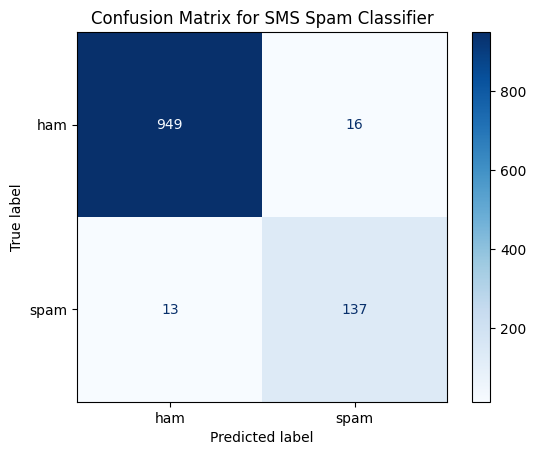

In [15]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if 'nb_classifier_sms' in locals() and X_test_sms is not None and y_test_sms is not None:
    # Make predictions on the test set
    y_pred_sms = nb_classifier_sms.predict(X_test_sms)

    # Calculate F1-score
    f1 = f1_score(y_test_sms, y_pred_sms)
    print(f"F1-score: {f1:.4f}")

    # Generate Confusion Matrix
    cm = confusion_matrix(y_test_sms, y_pred_sms)
    print(f"\nConfusion Matrix:\n{cm}")

    # Display Confusion Matrix visually
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix for SMS Spam Classifier')
    plt.show()
else:
    print("Classifier or test data not found for evaluation. Please ensure previous steps ran successfully.")

# Assignment 2:

##IMDB Movie Review Sentiment Analysis

Objective: Classify movie reviews as positive or negative using traditional machine learning algorithms.

### Extracting the dataset for Assignment 2

In [16]:
import zipfile
import os

# Path to the uploaded zip file for Assignment 2
zip_file_path_assignment2 = '/content/archive (6).zip'

# Directory to extract the contents (reuse the same extraction_path)
# extraction_path is already defined from Assignment 1 as '/content/datasets'

# Unzip the file
with zipfile.ZipFile(zip_file_path_assignment2, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Files from Assignment 2 extracted to: {extraction_path}")
print("Contents of the extracted directory (including new files):")
for root, dirs, files in os.walk(extraction_path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Files from Assignment 2 extracted to: /content/datasets
Contents of the extracted directory (including new files):
/content/datasets/spam.csv
/content/datasets/IMDB Dataset.csv


Dataset Link: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

IMDB dataset loaded from: /content/datasets/IMDB Dataset.csv
Initial IMDB DataFrame head:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
Initial IMDB DataFrame info:
None


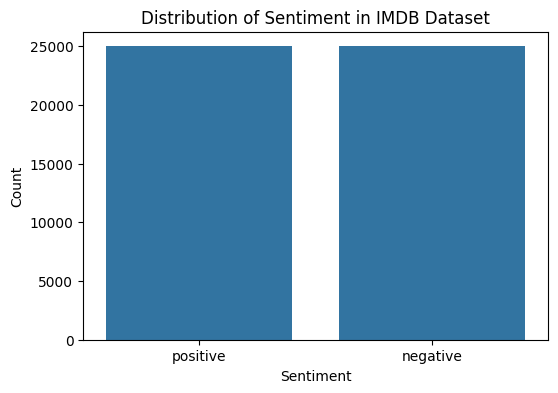


Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
The dataset is balanced with respect to sentiment classes.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define common possible paths for the IMDB dataset
possible_imdb_paths = [
    os.path.join(extraction_path, 'IMDB Dataset.csv'),
    os.path.join(extraction_path, 'imdb_dataset.csv'),
    os.path.join(extraction_path, 'imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
]

df_imdb = None
for path in possible_imdb_paths:
    if os.path.exists(path):
        df_imdb = pd.read_csv(path)
        print(f"IMDB dataset loaded from: {path}")
        break

if df_imdb is None:
    print("Could not find the IMDB dataset file. Please specify the correct file name and path from the extracted files.")
else:
    print(f"Initial IMDB DataFrame head:\n{df_imdb.head()}")
    print(f"Initial IMDB DataFrame info:\n{df_imdb.info()}")

    # Task 1: Perform exploratory data analysis (EDA) to check for class imbalances.
    plt.figure(figsize=(6, 4))
    sns.countplot(x='sentiment', data=df_imdb)
    plt.title('Distribution of Sentiment in IMDB Dataset')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.show()

    sentiment_counts = df_imdb['sentiment'].value_counts()
    print(f"\nSentiment distribution:\n{sentiment_counts}")
    if sentiment_counts['positive'] == sentiment_counts['negative']:
        print("The dataset is balanced with respect to sentiment classes.")
    else:
        print("The dataset shows class imbalance.")

Task 1:

Perform exploratory data analysis (EDA) to check for class imbalances.

Review length statistics (words):
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length_words, dtype: float64


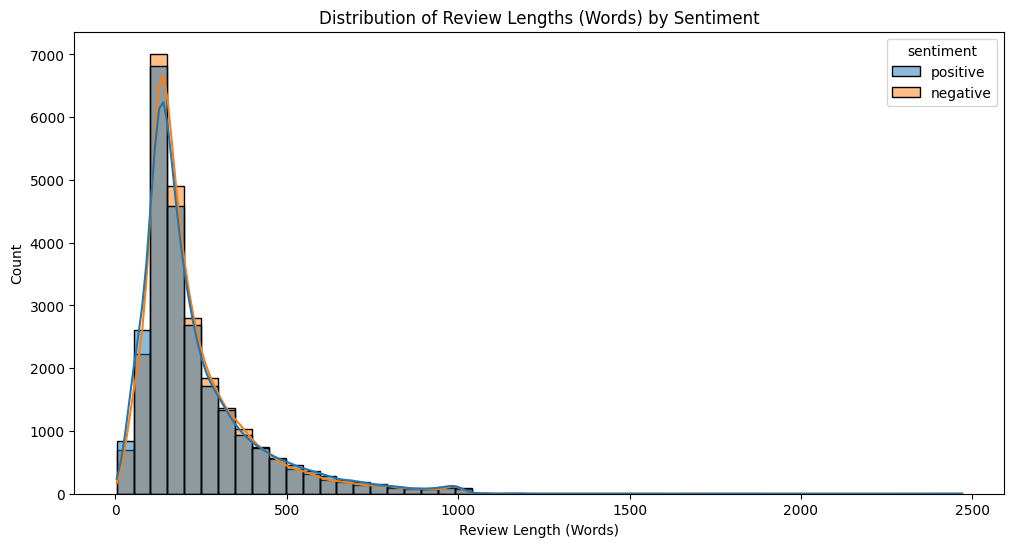


Review character length statistics:
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length_chars, dtype: float64


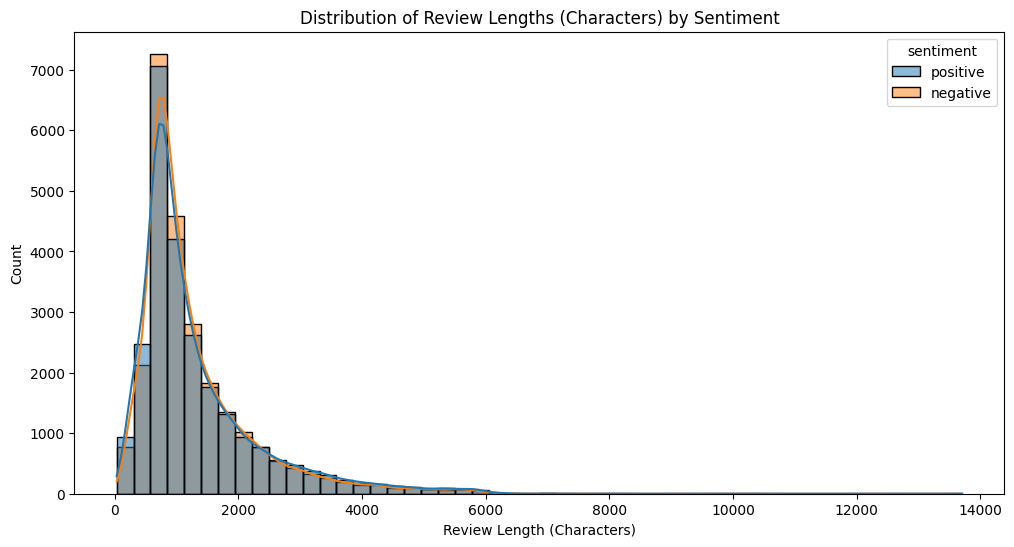

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_imdb is available and has a 'review' column
if 'df_imdb' in locals() and df_imdb is not None and 'review' in df_imdb.columns:
    # Calculate review lengths (number of words)
    df_imdb['review_length_words'] = df_imdb['review'].apply(lambda x: len(str(x).split()))

    print(f"Review length statistics (words):\n{df_imdb['review_length_words'].describe()}")

    # Visualize review length distribution by sentiment
    plt.figure(figsize=(12, 6))
    sns.histplot(data=df_imdb, x='review_length_words', hue='sentiment', kde=True, bins=50)
    plt.title('Distribution of Review Lengths (Words) by Sentiment')
    plt.xlabel('Review Length (Words)')
    plt.ylabel('Count')
    plt.show()

    # Also check character length
    df_imdb['review_length_chars'] = df_imdb['review'].apply(len)
    print(f"\nReview character length statistics:\n{df_imdb['review_length_chars'].describe()}")

    plt.figure(figsize=(12, 6))
    sns.histplot(data=df_imdb, x='review_length_chars', hue='sentiment', kde=True, bins=50)
    plt.title('Distribution of Review Lengths (Characters) by Sentiment')
    plt.xlabel('Review Length (Characters)')
    plt.ylabel('Count')
    plt.show()

else:
    print("IMDB DataFrame or 'review' column not found for review length analysis.")

# Note: This cell now performs EDA on review lengths.
# The previous text cleaning and lemmatization code has been replaced in this cell.
# If you intend to proceed with sentiment analysis, text preprocessing will need to be performed in a subsequent step.

Task 2:

Tokenize the reviews and apply Stemming or Lemmatization via the nltk library.

In [22]:
import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)


if df_imdb is not None and 'review' in df_imdb.columns:
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))

    def preprocess_text(text):
        # Remove HTML tags
        text = re.sub(r'<.*?>', '', text)
        # Remove punctuation and numbers
        text = re.sub(r'[^a-zA-Z]', ' ', text)
        # Convert to lowercase
        text = text.lower()
        # Tokenize words
        tokens = word_tokenize(text)
        # Remove stopwords and apply lemmatization
        tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
        # Join back into a string
        return ' '.join(tokens)

    df_imdb['cleaned_review'] = df_imdb['review'].apply(preprocess_text)
    print(f"\nCleaned IMDB DataFrame head:\n{df_imdb[['review', 'cleaned_review', 'sentiment']].head()}")


Cleaned IMDB DataFrame head:
                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review sentiment  
0  one reviewer mentioned watching oz episode hoo...  positive  
1  wonderful little production filming technique ...  positive  
2  thought wonderful way spend time hot summer we...  positive  
3  basically family little boy jake think zombie ...  negative  
4  petter mattei love time money visually stunnin...  positive  


Task 3:

Use TF-IDF text representation with an n-gram range of (1, 2) to capture two-word phrases.

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

if df_imdb is not None and 'cleaned_review' in df_imdb.columns:
    # Initialize TfidfVectorizer with n-gram range (1, 2)
    tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000) # Limiting features for manageability

    # Fit and transform the cleaned movie reviews
    X_imdb = tfidf_vectorizer.fit_transform(df_imdb['cleaned_review'])

    print(f"Shape of vectorized IMDB data: {X_imdb.shape}")
    print(f"First 50 feature names (TF-IDF):\n{tfidf_vectorizer.get_feature_names_out()[:50]}")
else:
    print("IMDB DataFrame or 'cleaned_review' column not found for TF-IDF vectorization.")

Shape of vectorized IMDB data: (50000, 5000)
First 50 feature names (TF-IDF):
['abandoned' 'abc' 'ability' 'able' 'absence' 'absolute' 'absolutely'
 'absolutely nothing' 'absurd' 'abuse' 'abysmal' 'academy' 'academy award'
 'accent' 'accept' 'acceptable' 'accepted' 'accident' 'accidentally'
 'accompanied' 'accomplished' 'according' 'account' 'accurate' 'accused'
 'achieve' 'achieved' 'achievement' 'across' 'act' 'act like' 'acted'
 'acting' 'acting bad' 'acting good' 'acting great' 'acting terrible'
 'action' 'action film' 'action movie' 'action scene' 'action sequence'
 'activity' 'actor' 'actor actress' 'actor film' 'actor like'
 'actor movie' 'actor play' 'actress']


Task 4:

Train a Linear Support Vector Machine (LinearSVC) or Random Forest model.Test with custom text snippets written by yourself to observe real-time predictions.Compute Metrics

Shape of X_train_imdb: (40000, 5000)
Shape of X_test_imdb: (10000, 5000)
Shape of y_train_imdb: (40000,)
Shape of y_test_imdb: (10000,)

Training LinearSVC model...
LinearSVC model trained successfully.

F1-score for IMDB Sentiment Classifier: 0.8868

Confusion Matrix for IMDB Sentiment Classifier:
[[4350  611]
 [ 538 4501]]


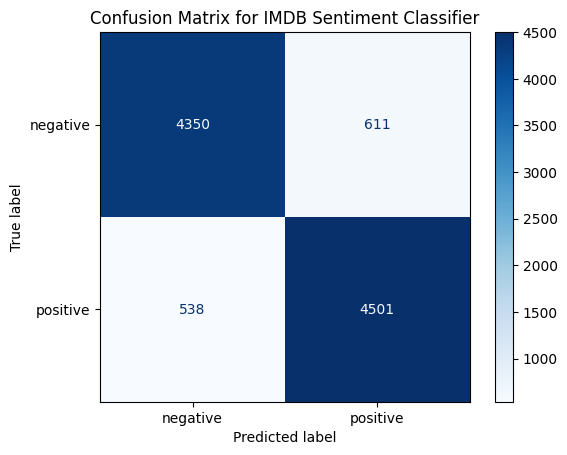


--- Testing with custom text snippets ---
Review: 'This movie was absolutely fantastic! The acting was superb and the plot was engaging.'
Predicted Sentiment: positive

Review: 'What a terrible film. I wasted two hours of my life watching this awful, boring mess.'
Predicted Sentiment: negative

Review: 'It had some good moments, but overall it was just okay, nothing special.'
Predicted Sentiment: negative



In [23]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

# Ensure NLTK resources are downloaded for custom text prediction function
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

if 'df_imdb' in locals() and df_imdb is not None and 'cleaned_review' in df_imdb.columns and 'X_imdb' in locals() and X_imdb is not None:
    # 1. Prepare labels
    label_encoder_imdb = LabelEncoder()
    y_imdb = label_encoder_imdb.fit_transform(df_imdb['sentiment'])

    # 2. Split data into training and testing sets
    X_train_imdb, X_test_imdb, y_train_imdb, y_test_imdb = train_test_split(X_imdb, y_imdb, test_size=0.2, random_state=42)

    print(f"Shape of X_train_imdb: {X_train_imdb.shape}")
    print(f"Shape of X_test_imdb: {X_test_imdb.shape}")
    print(f"Shape of y_train_imdb: {y_train_imdb.shape}")
    print(f"Shape of y_test_imdb: {y_test_imdb.shape}")

    # 3. Train a Linear Support Vector Machine (LinearSVC) classifier
    print("\nTraining LinearSVC model...")
    model_imdb = LinearSVC(random_state=42)
    model_imdb.fit(X_train_imdb, y_train_imdb)
    print("LinearSVC model trained successfully.")

    # 4. Evaluate performance
    y_pred_imdb = model_imdb.predict(X_test_imdb)

    f1_imdb = f1_score(y_test_imdb, y_pred_imdb)
    print(f"\nF1-score for IMDB Sentiment Classifier: {f1_imdb:.4f}")

    cm_imdb = confusion_matrix(y_test_imdb, y_pred_imdb)
    print(f"\nConfusion Matrix for IMDB Sentiment Classifier:\n{cm_imdb}")

    disp_imdb = ConfusionMatrixDisplay(confusion_matrix=cm_imdb, display_labels=label_encoder_imdb.classes_)
    disp_imdb.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix for IMDB Sentiment Classifier')
    plt.show()

    # 5. Test with custom text snippets
    def preprocess_new_text(text, vectorizer, lemmatizer, stop_words):
        # Remove HTML tags
        text = re.sub(r'<.*?>', '', text)
        # Remove punctuation and numbers
        text = re.sub(r'[^a-zA-Z]', ' ', text)
        # Convert to lowercase
        text = text.lower()
        # Tokenize words
        tokens = word_tokenize(text)
        # Remove stopwords and apply lemmatization
        tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
        # Join back into a string
        processed_text = ' '.join(tokens)
        # Vectorize the processed text
        return vectorizer.transform([processed_text])

    def predict_sentiment(text_snippet, model, vectorizer, label_encoder, lemmatizer, stop_words):
        # Preprocess and vectorize the new text
        processed_vector = preprocess_new_text(text_snippet, vectorizer, lemmatizer, stop_words)
        # Predict sentiment
        prediction = model.predict(processed_vector)
        # Decode the numerical prediction back to sentiment label
        return label_encoder.inverse_transform(prediction)[0]

    print("\n--- Testing with custom text snippets ---")
    # Re-initialize lemmatizer and stop_words for the custom prediction function
    lemmatizer_for_pred = WordNetLemmatizer()
    stop_words_for_pred = set(stopwords.words('english'))

    custom_review_1 = "This movie was absolutely fantastic! The acting was superb and the plot was engaging."
    sentiment_1 = predict_sentiment(custom_review_1, model_imdb, tfidf_vectorizer, label_encoder_imdb, lemmatizer_for_pred, stop_words_for_pred)
    print(f"Review: '{custom_review_1}'\nPredicted Sentiment: {sentiment_1}\n")

    custom_review_2 = "What a terrible film. I wasted two hours of my life watching this awful, boring mess."
    sentiment_2 = predict_sentiment(custom_review_2, model_imdb, tfidf_vectorizer, label_encoder_imdb, lemmatizer_for_pred, stop_words_for_pred)
    print(f"Review: '{custom_review_2}'\nPredicted Sentiment: {sentiment_2}\n")

    custom_review_3 = "It had some good moments, but overall it was just okay, nothing special."
    sentiment_3 = predict_sentiment(custom_review_3, model_imdb, tfidf_vectorizer, label_encoder_imdb, lemmatizer_for_pred, stop_words_for_pred)
    print(f"Review: '{custom_review_3}'\nPredicted Sentiment: {sentiment_3}\n")

else:
    print("IMDB DataFrame, cleaned_review column, or X_imdb (vectorized features) not found. Please ensure previous steps ran successfully.")

#Assignment 3

##Fake News Detector

Objective: Identify whether a news article contains real or fabricated information.

Dataset link: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

Dataset separated in two files:

1. Fake.csv (23502 fake news article)
2. True.csv (21417 true news article)

Task 1:

Merge the true and fake datasets, adding a target binary column (0 for real, 1 for fake).

In [34]:
import pandas as pd
import os
try:
    df_true = pd.read_csv(os.path.join('/content/', 'True.csv'))
    df_true['target'] = 0 # Assign 0 for real news
    print(f"True news dataset loaded. Shape: {df_true.shape}")
    print(f"True news head:\n{df_true.head()}\n")
    df_fake = pd.read_csv(os.path.join('/content/', 'Fake.csv'))
    df_fake['target'] = 1 # Assign 1 for fake news
    print(f"Fake news dataset loaded. Shape: {df_fake.shape}")
    print(f"Fake news head:\n{df_fake.head()}\n")

    # Merge the two datasets
    df_news = pd.concat([df_true, df_fake], ignore_index=True)
    print(f"Merged dataset created. Total shape: {df_news.shape}")
    print(f"Merged dataset head:\n{df_news.head()}\n")
    print(f"Merged dataset tail:\n{df_news.tail()}\n")
    print(f"Target distribution in merged dataset:\n{df_news['target'].value_counts()}\n")

except FileNotFoundError as e:
    print(f"Error: One of the CSV files not found. Please ensure 'True.csv' and 'Fake.csv' are in the expected directory. Details: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

True news dataset loaded. Shape: (21417, 5)
True news head:
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  target  
0  December 31, 2017        0  
1  December 29, 2017        0  
2  December 31, 2017        0  
3  December 30, 2017        0  
4  December 29, 2017  

Task 2:

Concatenate the article title and text fields into a single text feature.

In [35]:
if 'df_news' in locals() and df_news is not None and 'title' in df_news.columns and 'text' in df_news.columns:
    # Fill NaN values in 'title' or 'text' with empty strings to avoid concatenation errors
    df_news['title'] = df_news['title'].fillna('')
    df_news['text'] = df_news['text'].fillna('')
    df_news['full_text'] = df_news['title'] + ' ' + df_news['text']
    print(f"'full_text' feature created. Head of new column:\n{df_news[['title', 'text', 'full_text']].head()}\n")
    print(f"'full_text' feature created. Tail of new column:\n{df_news[['title', 'text', 'full_text']].tail()}\n")
    print(f"Checking for any remaining NaN values in 'full_text': {df_news['full_text'].isnull().sum()}")
else:
    print("Merged news DataFrame (df_news) or required columns ('title', 'text') not found. Please ensure previous steps ran successfully.")

'full_text' feature created. Head of new column:
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text  \
0  WASHINGTON (Reuters) - The head of a conservat...   
1  WASHINGTON (Reuters) - Transgender people will...   
2  WASHINGTON (Reuters) - The special counsel inv...   
3  WASHINGTON (Reuters) - Trump campaign adviser ...   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...   

                                           full_text  
0  As U.S. budget fight looms, Republicans flip t...  
1  U.S. military to accept transgender recruits o...  
2  Senior U.S. Republican senator: 'Let Mr. Muell...  
3  FBI Russia probe helped by Australian diplomat...  
4 

Task 3:

Transform text using TF-IDF.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

if 'df_news' in locals() and df_news is not None and 'full_text' in df_news.columns:
    tfidf_vectorizer_news = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
    X_news_tfidf = tfidf_vectorizer_news.fit_transform(df_news['full_text'])
    print(f"Shape of vectorized news data (TF-IDF): {X_news_tfidf.shape}")
    print("First 50 feature names (TF-IDF):")
    print(tfidf_vectorizer_news.get_feature_names_out()[:50])
else:
    print("Merged news DataFrame (df_news) or 'full_text' column not found for TF-IDF vectorization. Please ensure previous steps ran successfully.")

Shape of vectorized news data (TF-IDF): (44898, 5000)
First 50 feature names (TF-IDF):
['000' '000 people' '10' '100' '100 000' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20' '200' '2001' '2005' '2006' '2007' '2008' '2009'
 '2010' '2011' '2012' '2013' '2014' '2015' '2016' '2016 election'
 '2016 presidential' '2017' '2017 realdonaldtrump' '2018' '2019' '21'
 '21st' '21st century' '21wire' '21wire tv' '22' '23' '24' '25' '26' '27'
 '28' '29' '30' '300']


Task 4:

Train a PassiveAggressiveClassifier—known to perform exceptionally well on text tracking shifting trends.Monitor accuracy over cross-validation folds.Compute relevant metrics

Shape of X_train: (35918, 5000)
Shape of X_test: (8980, 5000)
Shape of y_train: (35918,)
Shape of y_test: (8980,)

Training PassiveAggressiveClassifier model...
PassiveAggressiveClassifier model trained successfully.

Test Accuracy: 0.9967
Test F1-score: 0.9968

Confusion Matrix:
[[4266   18]
 [  12 4684]]


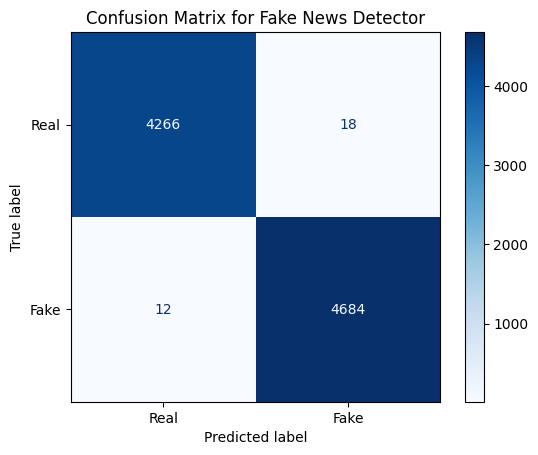


Monitoring accuracy over cross-validation folds...
Cross-validation accuracies: [0.99576837 0.99565702 0.99621381 0.9965475  0.99665887]
Mean CV accuracy: 0.9962
Standard deviation of CV accuracy: 0.0004


In [33]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

if 'df_news' in locals() and df_news is not None and 'target' in df_news.columns and 'X_news_tfidf' in locals() and X_news_tfidf is not None:
    X = X_news_tfidf
    y = df_news['target']

    # 1. Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"Shape of X_train: {X_train.shape}")
    print(f"Shape of X_test: {X_test.shape}")
    print(f"Shape of y_train: {y_train.shape}")
    print(f"Shape of y_test: {y_test.shape}")

    # 2. Train a PassiveAggressiveClassifier
    print("\nTraining PassiveAggressiveClassifier model...")
    pac = PassiveAggressiveClassifier(max_iter=1000, random_state=42, n_jobs=-1)
    pac.fit(X_train, y_train)
    print("PassiveAggressiveClassifier model trained successfully.")

    # 3. Evaluate performance on the test set
    y_pred = pac.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\nTest Accuracy: {accuracy:.4f}")
    print(f"Test F1-score: {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:\n{cm}")

    # Display Confusion Matrix visually
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix for Fake News Detector')
    plt.show()

    # 4. Monitor accuracy over cross-validation folds
    print("\nMonitoring accuracy over cross-validation folds...")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pac, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

    print(f"Cross-validation accuracies: {cv_scores}")
    print(f"Mean CV accuracy: {np.mean(cv_scores):.4f}")
    print(f"Standard deviation of CV accuracy: {np.std(cv_scores):.4f}")
else:
    print("Required data (df_news with 'target' or X_news_tfidf) not found. Please ensure previous steps ran successfully.")